<a href="https://colab.research.google.com/github/Nicky-Georgia/ECG_disease_classification/blob/main/deep_learning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import warnings
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score

from torch.utils.data import Dataset, DataLoader, random_split

path = kagglehub.dataset_download("shayanfazeli/heartbeat")
warnings.filterwarnings('ignore')
mitbih_train = pd.read_csv(path + '/mitbih_train.csv')
mitbih_test = pd.read_csv(path + '/mitbih_test.csv')

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
data_train, data_val = train_test_split(np.array(mitbih_train), test_size= 0.2)
X_train, y_train = data_train[:, :-1], data_train[:, -1].astype(int)
X_val, y_val = data_val[:, :-1], data_val[:, -1].astype(int)
X_test, y_test = np.array(mitbih_test)[:, :-1], np.array(mitbih_test)[:, -1].astype(int)

In [ ]:
def one_hot_encode(array, num_classes=5):

    one_hot_encoded = np.zeros((array.size, num_classes), dtype=int)

    one_hot_encoded[np.arange(array.size), array] = 1

    return one_hot_encoded


In [ ]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(one_hot_encode(y), dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx]

In [ ]:
dataset_test = Dataset(X_test, y_test)
dataset_train = Dataset(X_train,y_train)
dataset_val = Dataset(X_val,y_val)

test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=64, shuffle=True)
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=64, shuffle=True)

In [ ]:
class BasicModel_dd(nn.Module):
    def __init__(self,input,output):
        super().__init__()
        self.linear = nn.Sequential(
        nn.Linear(input,128),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(128,256),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,output),
        nn.Sigmoid()
        )
    def forward(self, x):
        out = self.linear(x)
        return out

In [ ]:
model = BasicModel_dd(187,5)
model.to(device)
epoch_count = 10
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_func(model,epoch_count,criterion,optimizer,test_loader,train_loader,val_loader):
    train_losses, val_losses = [],[]
    for epoch in range(epoch_count):
        # Training phase
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device),targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        # Validation phase
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device),targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        print(f'Epoch [{epoch+1}/{epoch_count}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    # Testing phase
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    print(f'Test Loss: {test_loss:.4f}')

    print("Training and evaluation complete.")
    return train_losses, val_losses

In [ ]:
train_func(model,epoch_count,criterion,optimizer,test_loader,train_loader,val_loader)

Epoch [1/10], Train Loss: 0.0242, Val Loss: 0.0289
Epoch [2/10], Train Loss: 0.0232, Val Loss: 0.0287
Epoch [3/10], Train Loss: 0.0228, Val Loss: 0.0282
Epoch [4/10], Train Loss: 0.0224, Val Loss: 0.0291
Epoch [5/10], Train Loss: 0.0226, Val Loss: 0.0278
Epoch [6/10], Train Loss: 0.0225, Val Loss: 0.0261
Epoch [7/10], Train Loss: 0.0225, Val Loss: 0.0320


In [ ]:
result = model(torch.tensor(X_test, dtype=torch.float32).to(device))
_, res = torch.max(result, dim=1)
print(f1_score(y_test,res.cpu(),average='macro'))

0.8804741858606013


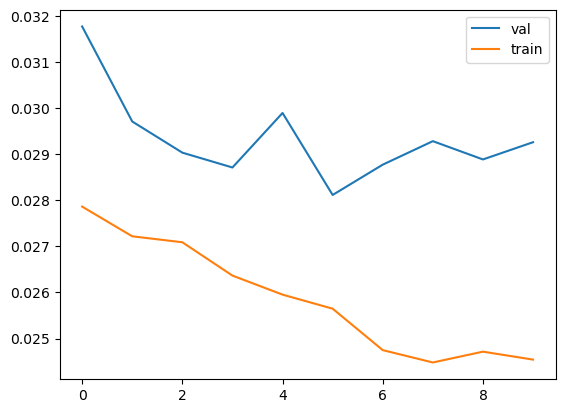

In [ ]:
plt.plot(val_losses, label = 'val')
plt.plot(train_losses, label = 'train')
plt.legend()

In [ ]:
# CNN Model for Heartbeat Classification
class CNN_Model(nn.Module):
    def __init__(self, input_size=187, num_classes=5):
        super(CNN_Model, self).__init__()

        # First conv block
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)
        self.dropout1 = nn.Dropout(0.2)

        # Second conv block
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)
        self.dropout2 = nn.Dropout(0.3)

        # Third conv block
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool3 = nn.MaxPool1d(2)
        self.dropout3 = nn.Dropout(0.3)

        # Calculate the size after convolutions
        self.fc_input_size = 128 * (input_size // 8)  # After 3 pooling layers (2^3 = 8)

        # Fully connected layers
        self.fc1 = nn.Linear(self.fc_input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.dropout_fc = nn.Dropout(0.5)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Reshape for 1D convolution: (batch, 1, sequence_length)
        x = x.unsqueeze(1)

        # First conv block
        x = self.pool1(self.dropout1(self.bn1(self.relu(self.conv1(x)))))

        # Second conv block
        x = self.pool2(self.dropout2(self.bn2(self.relu(self.conv2(x)))))

        # Third conv block
        x = self.pool3(self.dropout3(self.bn3(self.relu(self.conv3(x)))))

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = self.dropout_fc(self.relu(self.fc1(x)))
        x = self.dropout_fc(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

# RNN Model for Heartbeat Classification
class RNN_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, num_classes=5, sequence_length=187):
        super(RNN_Model, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.sequence_length = sequence_length

        # LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.3, bidirectional=True)

        # Attention mechanism
        self.attention = nn.Linear(hidden_size * 2, 1)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size * 2, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Reshape for LSTM: (batch, sequence_length, input_size)
        x = x.unsqueeze(2)

        # LSTM forward pass
        lstm_out, _ = self.lstm(x)

        # Attention mechanism
        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        attended_output = torch.sum(attention_weights * lstm_out, dim=1)

        # Fully connected layers
        x = self.dropout(self.relu(self.fc1(attended_output)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

# Alternative: Simple RNN without attention
class SimpleRNN_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, num_classes=5):
        super(SimpleRNN_Model, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layers (often performs better than vanilla RNN)
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                         batch_first=True, dropout=0.3)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Reshape for GRU: (batch, sequence_length, input_size)
        x = x.unsqueeze(2)

        # GRU forward pass - only use the last output
        gru_out, _ = self.gru(x)
        x = gru_out[:, -1, :]  # Take the last time step

        # Fully connected layers
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, device='cpu'):
    model.to(device)
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            _, target_labels = torch.max(targets.data, 1)
            train_total += targets.size(0)
            train_correct += (predicted == target_labels).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                _, target_labels = torch.max(targets.data, 1)
                val_total += targets.size(0)
                val_correct += (predicted == target_labels).sum().item()

        # Calculate metrics
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        train_losses.append(train_loss_avg)
        val_losses.append(val_loss_avg)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if epoch % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss_avg:.4f}, Val Acc: {val_acc:.2f}%')
            print('-' * 50)

    return train_losses, val_losses, train_accuracies, val_accuracies

# Evaluation function
def evaluate_model(model, test_loader, device='cpu'):
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            _, target_labels = torch.max(targets.data, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target_labels.cpu().numpy())

    accuracy = 100 * sum(p == t for p, t in zip(all_predictions, all_targets)) / len(all_targets)
    f1 = f1_score(all_targets, all_predictions, average='weighted')

    print(f'Test Accuracy: {accuracy:.2f}%')
    print(f'F1 Score: {f1:.4f}')

    return accuracy, f1, all_predictions, all_targets



In [ ]:
# Example usage:
if __name__ == "__main__":
    # Initialize models
    cnn_model = CNN_Model(input_size=187, num_classes=5)
    rnn_model = RNN_Model(input_size=1, hidden_size=128, num_layers=2, num_classes=5)
    simple_rnn_model = SimpleRNN_Model(input_size=1, hidden_size=128, num_layers=2, num_classes=5)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()

    # Train CNN Model
    print("Training CNN Model...")
    cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)
    cnn_train_losses, cnn_val_losses, cnn_train_acc, cnn_val_acc = train_model(
        cnn_model, train_loader, val_loader, criterion, cnn_optimizer, num_epochs=30, device=device
    )

    # Evaluate CNN
    print("\nEvaluating CNN Model:")
    cnn_accuracy, cnn_f1, _, _ = evaluate_model(cnn_model, test_loader, device)

    print("\n" + "="*60 + "\n")

    # Train RNN Model (with attention)
    print("Training RNN Model (LSTM with Attention)...")
    rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001, weight_decay=1e-4)
    rnn_train_losses, rnn_val_losses, rnn_train_acc, rnn_val_acc = train_model(
        rnn_model, train_loader, val_loader, criterion, rnn_optimizer, num_epochs=30, device=device
    )

    # Evaluate RNN
    print("\nEvaluating RNN Model:")
    rnn_accuracy, rnn_f1, _, _ = evaluate_model(rnn_model, test_loader, device)

    print("\n" + "="*60 + "\n")

    # Train Simple RNN Model
    print("Training Simple RNN Model (GRU)...")
    simple_rnn_optimizer = optim.Adam(simple_rnn_model.parameters(), lr=0.001, weight_decay=1e-4)
    simple_rnn_train_losses, simple_rnn_val_losses, simple_rnn_train_acc, simple_rnn_val_acc = train_model(
        simple_rnn_model, train_loader, val_loader, criterion, simple_rnn_optimizer, num_epochs=30, device=device
    )

    # Evaluate Simple RNN
    print("\nEvaluating Simple RNN Model:")
    simple_rnn_accuracy, simple_rnn_f1, _, _ = evaluate_model(simple_rnn_model, test_loader, device)

    # Plot training history
    plt.figure(figsize=(15, 5))

    # Loss plots
    plt.subplot(1, 3, 1)
    plt.plot(cnn_train_losses, label='CNN Train')
    plt.plot(cnn_val_losses, label='CNN Val')
    plt.plot(rnn_train_losses, label='RNN Train')
    plt.plot(rnn_val_losses, label='RNN Val')
    plt.plot(simple_rnn_train_losses, label='Simple RNN Train')
    plt.plot(simple_rnn_val_losses, label='Simple RNN Val')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plots
    plt.subplot(1, 3, 2)
    plt.plot(cnn_train_acc, label='CNN Train')
    plt.plot(cnn_val_acc, label='CNN Val')
    plt.plot(rnn_train_acc, label='RNN Train')
    plt.plot(rnn_val_acc, label='RNN Val')
    plt.plot(simple_rnn_train_acc, label='Simple RNN Train')
    plt.plot(simple_rnn_val_acc, label='Simple RNN Val')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    # Test results comparison
    plt.subplot(1, 3, 3)
    models = ['CNN', 'RNN (LSTM)', 'Simple RNN (GRU)']
    accuracies = [cnn_accuracy, rnn_accuracy, simple_rnn_accuracy]
    f1_scores = [cnn_f1, rnn_f1, simple_rnn_f1]

    x = np.arange(len(models))
    width = 0.35

    plt.bar(x - width/2, accuracies, width, label='Accuracy (%)')
    plt.bar(x + width/2, [f*100 for f in f1_scores], width, label='F1 Score (%)')
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.title('Test Performance Comparison')
    plt.xticks(x, models)
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("\nFinal Results Summary:")
    print(f"CNN Model - Accuracy: {cnn_accuracy:.2f}%, F1: {cnn_f1:.4f}")
    print(f"RNN Model (LSTM) - Accuracy: {rnn_accuracy:.2f}%, F1: {rnn_f1:.4f}")
    print(f"Simple RNN (GRU) - Accuracy: {simple_rnn_accuracy:.2f}%, F1: {simple_rnn_f1:.4f}")

In [ ]:
cnn_model = CNN_Model(input_size=187, num_classes=5)
    rnn_model = RNN_Model(input_size=1, hidden_size=128, num_layers=2, num_classes=5)
    simple_rnn_model = SimpleRNN_Model(input_size=1, hidden_size=128, num_layers=2, num_classes=5)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()